# Analisis Senyar Cylone

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
# melihat data single layer harian ERA5_Reanalysis
path_top = Path("D:/ERA5_REANALYSIS")
ds = xr.open_dataset(path_top / "ERA5_SingleLevel_DailyMean_20250101-20260331.nc", engine="netcdf4")

display(ds)

<xarray.Dataset> Size: 196MB
Dimensions:     (valid_time: 455, latitude: 50, longitude: 77)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 400B 10.75 10.5 10.25 ... -1.0 -1.25 -1.5
  * longitude   (longitude) float64 616B 93.0 93.25 93.5 ... 111.5 111.8 112.0
    number      int64 8B ...
Data variables: (12/28)
    u100        (valid_time, latitude, longitude) float32 7MB ...
    v100        (valid_time, latitude, longitude) float32 7MB ...
    v10n        (valid_time, latitude, longitude) float32 7MB ...
    v10         (valid_time, latitude, longitude) float32 7MB ...
    t2m         (valid_time, latitude, longitude) float32 7MB ...
    cp          (valid_time, latitude, longitude) float32 7MB ...
    ...          ...
    tvh         (valid_time, latitude, longitude) float32 7MB ...
    tvl         (valid_time, latitude, longitude) float32 7MB ...
    swvl1       (valid_time, latitude, longitude) float32 7MB ...
    swvl2       (valid_time, latitude, longitude) float32 7MB ...
    swvl3       (valid_time, latitude, longitude) float32 7MB ...
    swvl4       (valid_time, latitude, longitude) float32 7MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 Merged all variable files from ERA5_SingleLevel_...

In [58]:
# get the latitude and longitude bounds for Medan city
lat_min, lat_max = 3.3833, 3.7500  # Approximate latitude bounds for Medan
lon_min, lon_max = 98.3333, 98.7500  # Approximate longitude bounds for Medan

# Select data within the specified bounds
ds_medan = ds.sel(latitude=slice(lat_max, lat_min), longitude=slice(lon_min, lon_max))

# Display the selected dataset
print("Dataset for Medan:")
display(ds_medan)

# Calculate the number of grid points
num_grids = len(ds_medan.latitude) * len(ds_medan.longitude)
print(f"Number of grids used: {num_grids}")

# Convert to DataFrame
df_medan = ds_medan.to_dataframe().reset_index()
print("\nDataFrame for Medan:")
display(df_medan)

Dataset for Medan:


<xarray.Dataset> Size: 208kB
Dimensions:     (valid_time: 455, latitude: 2, longitude: 2)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 4kB 2025-01-01 ... 2026-03-31
  * latitude    (latitude) float64 16B 3.75 3.5
  * longitude   (longitude) float64 16B 98.5 98.75
    number      int64 8B ...
Data variables: (12/28)
    u100        (valid_time, latitude, longitude) float32 7kB ...
    v100        (valid_time, latitude, longitude) float32 7kB ...
    v10n        (valid_time, latitude, longitude) float32 7kB ...
    v10         (valid_time, latitude, longitude) float32 7kB ...
    t2m         (valid_time, latitude, longitude) float32 7kB ...
    cp          (valid_time, latitude, longitude) float32 7kB ...
    ...          ...
    tvh         (valid_time, latitude, longitude) float32 7kB ...
    tvl         (valid_time, latitude, longitude) float32 7kB ...
    swvl1       (valid_time, latitude, longitude) float32 7kB ...
    swvl2       (valid_time, latitude, longitude) float32 7kB ...
    swvl3       (valid_time, latitude, longitude) float32 7kB ...
    swvl4       (valid_time, latitude, longitude) float32 7kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 Merged all variable files from ERA5_SingleLevel_...

Number of grids used: 4

DataFrame for Medan:


,valid_time,latitude,longitude,u100,v100,v10n,v10,t2m,cp,crr,...,tclw,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number
0,2025-01-01,3.75,98.50,1.068951,-0.314060,-0.230350,-0.077847,300.597656,0.000013,7.212162e-06,...,0.073273,0.001495,0.000031,6.0,1.0,0.408256,0.413693,0.418091,0.424625,0
1,2025-01-01,3.75,98.75,1.730816,-0.766453,-0.704227,-0.503872,300.663086,0.000040,1.847744e-06,...,0.049057,0.002228,0.000055,6.0,1.0,0.424888,0.431805,0.423523,0.443874,0
2,2025-01-01,3.50,98.50,1.020611,-0.483494,0.215694,0.311314,299.270508,0.000141,0.000000e+00,...,0.113022,0.002350,0.000162,6.0,1.0,0.398418,0.403366,0.420986,0.429108,0
3,2025-01-01,3.50,98.75,2.098248,-0.485935,-0.044315,0.106236,300.056152,0.000473,6.437302e-06,...,0.104240,0.000885,0.000512,6.0,1.0,0.424282,0.430962,0.412083,0.449337,0
4,2025-01-02,3.75,98.50,1.815887,-1.117908,-0.691376,-0.609913,300.938782,0.000069,4.172325e-07,...,0.142471,0.004547,0.000112,6.0,1.0,0.398987,0.401205,0.414145,0.424240,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1815,2026-03-30,3.50,98.75,-0.833660,1.140862,0.922356,0.921997,300.243835,0.000690,6.437302e-06,...,0.070389,0.001129,0.000692,6.0,1.0,0.352856,0.284421,0.274073,0.398453,0
1816,2026-03-31,3.75,98.50,-0.774933,-0.165180,0.136150,0.074902,300.375977,0.000088,8.994341e-05,...,0.070824,0.006195,0.000107,6.0,1.0,0.319237,0.285139,0.284910,0.367722,0
1817,2026-03-31,3.75,98.75,-1.088898,0.341412,0.419598,0.381298,300.438477,0.000135,1.385808e-05,...,0.041374,0.001282,0.000161,6.0,1.0,0.394364,0.338659,0.346708,0.402294,0
1818,2026-03-31,3.50,98.50,-0.800079,0.250591,0.500652,0.414013,298.729492,0.000219,1.044869e-04,...,0.087669,0.010803,0.000235,6.0,1.0,0.396851,0.361761,0.280874,0.376953,0


,valid_time,latitude,longitude,u100,v100,v10n,v10,t2m,cp,crr,...,tclw,tcrw,tp,tvh,tvl,swvl1,swvl2,swvl3,swvl4,number
0,2025-01-01,3.625,98.625,1.479656,-0.512486,-0.190800,-0.041042,300.146851,0.000167,0.000004,...,0.084898,0.001740,0.000190,6.0,1.0,0.413961,0.419957,0.418671,0.436736,0.0
1,2025-01-02,3.625,98.625,2.084991,-1.309742,-0.718475,-0.624744,300.560120,0.000116,0.000012,...,0.156357,0.011848,0.000193,6.0,1.0,0.407866,0.409235,0.414590,0.436193,0.0
2,2025-01-03,3.625,98.625,3.023396,-0.478245,-0.006859,0.067612,299.761353,0.000039,0.000337,...,0.257616,0.018585,0.000051,6.0,1.0,0.418203,0.414524,0.411155,0.435646,0.0
3,2025-01-04,3.625,98.625,0.738224,-0.343590,-0.101223,0.040268,299.695374,0.000148,0.000041,...,0.166420,0.005020,0.000173,6.0,1.0,0.414211,0.416540,0.408321,0.435102,0.0
4,2025-01-05,3.625,98.625,-0.880718,0.061317,0.227398,0.252544,299.679626,0.001077,0.000063,...,0.073118,0.014137,0.001114,6.0,1.0,0.421096,0.423751,0.407620,0.434515,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2026-03-27,3.625,98.625,1.670738,-0.399265,-0.100006,-0.001007,301.014343,0.000002,0.000001,...,0.034958,0.000168,0.000002,6.0,1.0,0.259181,0.294474,0.302102,0.387923,0.0
451,2026-03-28,3.625,98.625,0.947590,0.327297,0.226406,0.318268,299.959961,0.000438,0.000007,...,0.097977,0.003380,0.000551,6.0,1.0,0.289485,0.288340,0.300638,0.387500,0.0
452,2026-03-29,3.625,98.625,-0.821697,0.724987,0.605732,0.568947,299.952026,0.000263,0.000011,...,0.154362,0.005463,0.000288,6.0,1.0,0.345517,0.293268,0.298939,0.387089,0.0
453,2026-03-30,3.625,98.625,-0.827984,0.628166,0.648552,0.580505,300.427063,0.000661,0.000101,...,0.065815,0.002060,0.000666,6.0,1.0,0.347716,0.302342,0.296844,0.386654,0.0


,valid_time,tp
0,2025-01-01,0.190049
1,2025-01-02,0.192583
2,2025-01-03,0.050992
3,2025-01-04,0.173122
4,2025-01-05,1.114011
...,...,...
450,2026-03-27,0.002265
451,2026-03-28,0.550807
452,2026-03-29,0.288397
453,2026-03-30,0.665933


<Axes: title={'center': 'Daily Total Precipitation in Medan (mm)'}, xlabel='valid_time'>

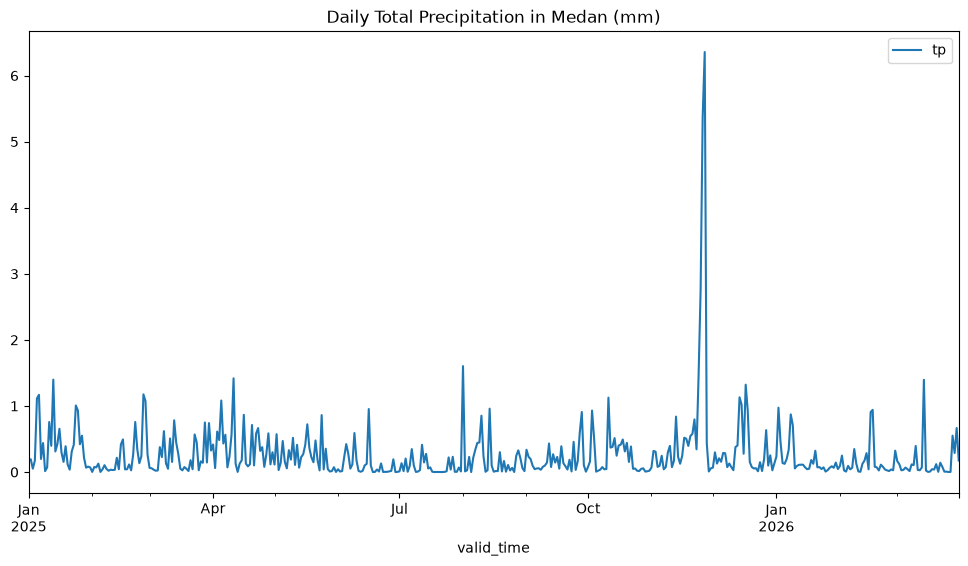

In [59]:
# Calculate the mean for each valid_time
df_medan_mean_time = df_medan.groupby('valid_time').mean().reset_index()
display(df_medan_mean_time)

# Plotting daily total precipitation in Medan
daily_tp = df_medan_mean_time[['valid_time', 'tp']].copy()
daily_tp['tp'] = daily_tp['tp'] * 1000  # Convert from meters to millimeters
display(daily_tp)
daily_tp.plot(kind='line', x='valid_time', y='tp', figsize=(12, 6), title='Daily Total Precipitation in Medan (mm)')

Tabel berikut merinci kepanjangan dari singkatan nama variabel pada dataset `ds` beserta satuannya, diformat menggunakan LaTeX untuk keperluan ilmiah:

Daftar Variabel Dataset ERA5 beserta Kepanjangan dan Satuannya
1. u10      : 10 metre U wind component $(m/s)$ 
2. v10      : 10 metre V wind component $(m/s)$ 
3. u100     : 100 metre U wind component $(m/s)$ 
4. v100     : 100 metre V wind component $(m/s)$ 
5. v10n     : 10 metre V wind component (neutral) $(m/s)$ 
6. t2m      : 2 metre temperature $(Kelvin)$
7. cp       : Convective precipitation $(meter)$
8. crr      : Convective rain rate $(kg/m^{2}.s)$
9. cvh      : Convective precipitation rate $(kg/m^{2}.s)$
10. lsp     : Large scale precipitation $(meter)$
11. lspf    : Large scale precipitation rate $(kg/m^{2}.s)$
12. lsrr    : Large scale rain rate $(kg/m^{2}.s)$
13. cvl     : Convective snow rate $(kg/m^{2}.s)$
14. msl     : Mean sea level pressure $(Pascal)$
15. ro      : Runoff $(meter)$
16. sst     : Sea surface temperature $(Kelvin)$
17. skt     : Skin temperature $(Kelvin)$
18. sp      : Surface pressure $(Pascal)$
19. sro     : Surface runoff $(meter)$
20. tcc     : Total cloud cover (0 - 1)
21. tclw    : Total column liquid water $(kg/m^{2})$
22. tcrw    : Total column rain water $(kg/m^{2})$
23. tp      : Total precipitation $(meter)$
24. tvh     : Total column vertically integrated heat/moisture -
25. tvl     : Total column vertically integrated liquid -
26. swvl1   : Soil water level 1 $(m^3.m^{-3})$
27. swvl2   : Soil water level 2 $(m^3.m^{-3})$
28. swvl3   : Soil water level 3 $(m^3.m^{-3})$
29. swvl4   : Soil water level 4 $(m^3.m^{-3})$